# OSM Patch Processor Demo

This notebook shows a minimal one-patch workflow.

In [89]:
# ============================================================
# Cell 1 — Imports and module reload
# ============================================================
#
# Purpose
# -------
# This cell imports the main class and supporting libraries used
# in the demo notebook.
#
# Why reload the module?
# ----------------------
# During development, the file `osm_patch_processor.py` may be
# edited multiple times. Reloading the module ensures that the
# notebook uses the latest version of the class without needing
# to close and reopen the notebook.
#
# Imported components
# -------------------
# - Path:
#     convenient path handling for files and folders
# - importlib:
#     allows reloading a Python module after editing it
# - osm_patch_processor:
#     the custom module containing the OSMPatchProcessor class
# - OSMPatchProcessor:
#     the main class used throughout the notebook
# - geopandas:
#     used to read and inspect cached vector files such as .gpkg
# ============================================================

# Standard library helper for working with filesystem paths
from pathlib import Path

# Import the custom module so it can be reloaded after code changes
import importlib
import osm_patch_processor

# Reload the module to ensure the notebook uses the latest saved version
importlib.reload(osm_patch_processor)

# Import the main class from the reloaded module
from osm_patch_processor import OSMPatchProcessor

# GeoPandas is used for reading cached OSM vector files and inspecting them
import geopandas as gpd

import numpy as np

In [82]:
# ============================================================
# Cell 2 — Create the main OSM patch processor
# ============================================================
#
# Purpose
# -------
# This cell defines the input patch metadata file and the root
# output directory, then creates an instance of the
# `OSMPatchProcessor` class.
#
# What this processor will do
# ---------------------------
# The processor object is the central interface used throughout
# the notebook. It is responsible for:
# 1. reading the patch metadata CSV
# 2. validating that the required columns exist
# 3. downloading OSM features for each patch
# 4. caching downloaded vector files
# 5. summarising available semantic keys and values
# 6. creating visualisations and raster masks
#
# Inputs
# ------
# PATCH_CSV:
#     path to the metadata CSV describing the image patches
# OUTPUT_DIR:
#     root folder where all generated outputs will be stored
#
# Important note
# --------------
# The CSV should contain patch-level metadata such as:
# - filename
# - filepath
# - CRS
# - image width and height
# - projected bounds
# - WGS84 bounds
# ============================================================

# Path to the patch metadata CSV file.
# This file contains one row per image patch and provides the
# spatial information needed to query the matching OSM extent.
PATCH_CSV = "image_metadata_summary.csv"

# Root output directory where all processor outputs will be saved.
# This may include:
# - cached OSM vector downloads
# - per-patch summaries
# - binary masks
# - multiclass masks
# - quick-look plots
OUTPUT_DIR = "osm_patch_outputs"

# Create the main processor object.
# This object will be reused in later cells for downloading,
# exploring, plotting, and exporting OSM-derived outputs.
processor = OSMPatchProcessor(
    # Patch metadata source, given here as a CSV file path
    patch_metadata=PATCH_CSV,

    # Folder where all generated outputs will be written
    output_dir=OUTPUT_DIR,

    # If True, print progress messages during processing
    # This is useful for debugging and tracking batch runs
    verbose=True,
)

In [83]:
# ============================================================
# Cell 3 — Process all patches and return results in memory
# ============================================================
#
# Purpose
# -------
# This cell processes all patches listed in the metadata CSV by:
# 1. downloading or loading cached OSM features for each patch
# 2. summarising available semantic keys
# 3. summarising the most frequent values for selected keys
# 4. returning the processed outputs in memory for later use
#
# What this method uses
# ---------------------
# - exact patch bounds from the metadata CSV
# - the processor's default semantic key list, unless overridden
# - cached vector files when available
#
# Why return results?
# -------------------
# Setting `return_results=True` makes the method return a Python
# dictionary so that the notebook can immediately inspect and use
# the downloaded data without re-reading it from disk.
#
# Structure of the returned object
# --------------------------------
# `results` is a dictionary where:
# - each key is a patch filename, e.g. "aachen_1.tif"
# - each value is another dictionary with:
#     - "gdf"         : GeoDataFrame of OSM features for the patch
#     - "key_summary" : summary table of available keys
#     - "top_values"  : top values for selected semantic keys
#
# Important note
# --------------
# If cached vector files already exist, the processor will load
# them instead of querying OSM again. This makes repeated runs
# much faster and avoids unnecessary requests.
# ============================================================

# Process all patches listed in the metadata CSV
results = processor.process_all_patches(
    # None means: process all rows in the metadata table
    patch_ids=None,

    # None means: use the processor's default semantic key list
    # ["building", "highway", "landuse", "natural", "waterway",
    #  "railway", "amenity", "barrier", "man_made"]
    semantic_keys=None,

    # If True, reuse previously saved OSM vector downloads when available
    use_cache=True,

    # File format used for cached vector files
    # "gpkg" is recommended because it stores geometry and CRS robustly
    cache_format="gpkg",

    # If True, continue processing the remaining patches even if one fails
    continue_on_error=True,

    # If True, return the processed outputs as a Python dictionary
    # in addition to saving summaries on disk
    return_results=True,
)


Processing patch: aachen_1.tif
Loading cached OSM features: osm_patch_outputs/cache_vectors/aachen_1.gpkg
Done: aachen_1.tif | features: 90

Processing patch: aachen_10.tif
Loading cached OSM features: osm_patch_outputs/cache_vectors/aachen_10.gpkg
Done: aachen_10.tif | features: 73

Processing patch: aachen_11.tif
Loading cached OSM features: osm_patch_outputs/cache_vectors/aachen_11.gpkg
Done: aachen_11.tif | features: 66

Processing patch: aachen_12.tif
Loading cached OSM features: osm_patch_outputs/cache_vectors/aachen_12.gpkg
Done: aachen_12.tif | features: 684

Processing patch: aachen_13.tif
Loading cached OSM features: osm_patch_outputs/cache_vectors/aachen_13.gpkg
Done: aachen_13.tif | features: 202

Processing patch: kitsap_30.tif
Loading cached OSM features: osm_patch_outputs/cache_vectors/kitsap_30.gpkg
Done: kitsap_30.tif | features: 111

Processing patch: kitsap_39.tif
Loading cached OSM features: osm_patch_outputs/cache_vectors/kitsap_39.gpkg
Done: kitsap_39.tif | featu

In [84]:
# ============================================================
# Cell 4 — Inspect the returned batch-processing object
# ============================================================
#
# Purpose
# -------
# This cell performs a quick sanity check on the object returned
# by `processor.process_all_patches(...)`.
#
# Why this matters
# ----------------
# Before using the downloaded data in later cells, it is useful to
# confirm:
# 1. the type of the returned object
# 2. how many patches were successfully returned
# 3. which patch names are available as dictionary keys
#
# Expected result
# ---------------
# - `type(results)` should usually be `dict`
# - `len(results)` gives the number of processed patch entries
# - `list(results.keys())[:5]` shows the first few patch filenames
#
# This helps confirm that the batch-processing step worked and
# that the notebook can now access patch-level outputs by name.
# ============================================================

# Print the Python type of the returned object.
# In this workflow, `results` is expected to be a dictionary.
print(type(results))

# Print the number of patch entries stored in the dictionary.
# This gives a quick idea of how many patches were returned.
print(len(results))

# Show the first five patch names stored as dictionary keys.
# These keys can be used later to access the corresponding
# per-patch outputs.
list(results.keys())[:5]

<class 'dict'>
11


['aachen_1.tif',
 'aachen_10.tif',
 'aachen_11.tif',
 'aachen_12.tif',
 'aachen_13.tif']

In [85]:
# ============================================================
# Cell 5 — Load one cached patch vector file for inspection
# ============================================================
#
# Purpose
# -------
# This cell loads the cached OSM vector file for one selected patch
# from disk and inspects its content.
#
# Why this step is useful
# -----------------------
# Although the `results` dictionary already contains in-memory outputs,
# it is often useful to confirm that the cached file on disk can also be
# read correctly. This is especially helpful for:
# - checking that the export/cache step worked
# - reusing saved patch data in later sessions without rerunning downloads
# - debugging one patch independently from the full batch
#
# What this file contains
# -----------------------
# The `.gpkg` file is a GeoPackage containing the OSM features
# downloaded for the selected patch extent. It typically includes:
# - geometry
# - OSM tag columns such as building, highway, landuse, natural, etc.
# - optional metadata columns added during processing
#
# Variables created
# -----------------
# patch_id:
#     the selected patch filename
# patch_stem:
#     the filename without the `.tif` extension, used to build
#     the corresponding cache filename
# patch_gdf:
#     GeoDataFrame containing the cached OSM features for the patch
# ============================================================

# Select one patch by filename.
# This should match one of the patch names returned in the `results` dictionary
# and one of the filenames listed in the metadata CSV.
patch_id = "aachen_12.tif"

# Remove the ".tif" extension to get the base patch name.
# This is used to construct the expected cached GeoPackage filename.
patch_stem = patch_id.replace(".tif", "")

# Read the cached OSM vector file for the selected patch.
# The file is expected to be located inside:
#     osm_patch_outputs/cache_vectors/
# and to be named like:
#     aachen_12.gpkg
patch_gdf = gpd.read_file(f"osm_patch_outputs/cache_vectors/{patch_stem}.gpkg")

# Print the number of OSM features stored in the patch vector file.
# This gives a quick idea of how feature-rich the selected patch is.
print(len(patch_gdf))

# Display the first few rows of the GeoDataFrame.
# This helps inspect:
# - available columns
# - example tag values
# - geometry types
display(patch_gdf.head())

684


,element,id,highway,crossing,crossing:island,crossing:markings,kerb,tactile_paving,amenity,check_date:recycling,...,healthcare:speciality,description,image,fence_type,footway,mtb:scale,mtb:scale:uphill,type,source_patch,geometry
0,node,35856439,turning_circle,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,aachen_12.tif,POINT (292368.3 5627492.337)
1,node,109262629,turning_circle,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,aachen_12.tif,POINT (292015.766 5627563.012)
2,node,109263787,turning_circle,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,aachen_12.tif,POINT (292194.875 5627557.538)
3,node,109267588,turning_circle,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,aachen_12.tif,POINT (292273.631 5627748.353)
4,node,109267604,turning_circle,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,aachen_12.tif,POINT (292431.092 5627955.397)


In [86]:
# ============================================================
# Cell 6 — Summarise available OSM tag keys for one patch
# ============================================================
#
# Purpose
# -------
# This cell creates a compact summary of the OSM semantic keys
# present in the selected patch GeoDataFrame.
#
# Why this matters
# ----------------
# A single patch may contain many possible OSM columns, but not all
# of them are equally relevant. This summary helps answer:
# - which OSM keys are present in this patch?
# - which keys appear most often?
# - which semantic families are strong enough to explore further?
#
# How the summary works
# ---------------------
# The function `processor.summarise_tag_keys(...)` checks each column
# in the patch GeoDataFrame and counts how many rows contain a non-null
# value for that key.
#
# Example interpretation
# ----------------------
# If the summary shows:
# - building : high count
# - highway  : moderate count
# - waterway : low count
#
# this suggests that the patch is rich in building features, contains
# some road information, and only limited water-related information.
#
# Output
# ------
# `key_summary_df` is a pandas DataFrame with columns such as:
# - key   : OSM key name
# - count : number of features in the patch where this key is present
# ============================================================

# Build a summary table of available OSM keys for the selected patch.
# Each row corresponds to one semantic key found in the GeoDataFrame.
key_summary_df = processor.summarise_tag_keys(patch_gdf)

# Display the first 30 rows of the summary table.
# The table is usually sorted from the most frequent keys to the least frequent.
display(key_summary_df.head(30))

,key,count
0,building,376
1,addr:housenumber,299
2,addr:street,299
3,addr:city,296
4,addr:postcode,296
5,addr:country,294
6,highway,216
7,surface,106
8,amenity,53
9,name,43



[Warning] RGB image could not be loaded.
Patch image not found for 'aachen_13.tif'.
Checked the CSV 'filepath' value.
To fix this, either:
1. update the 'filepath' column in the patch metadata CSV, or
2. pass image_root='.../OpenEarthMap_wo_xBD' when creating OSMPatchProcessor.


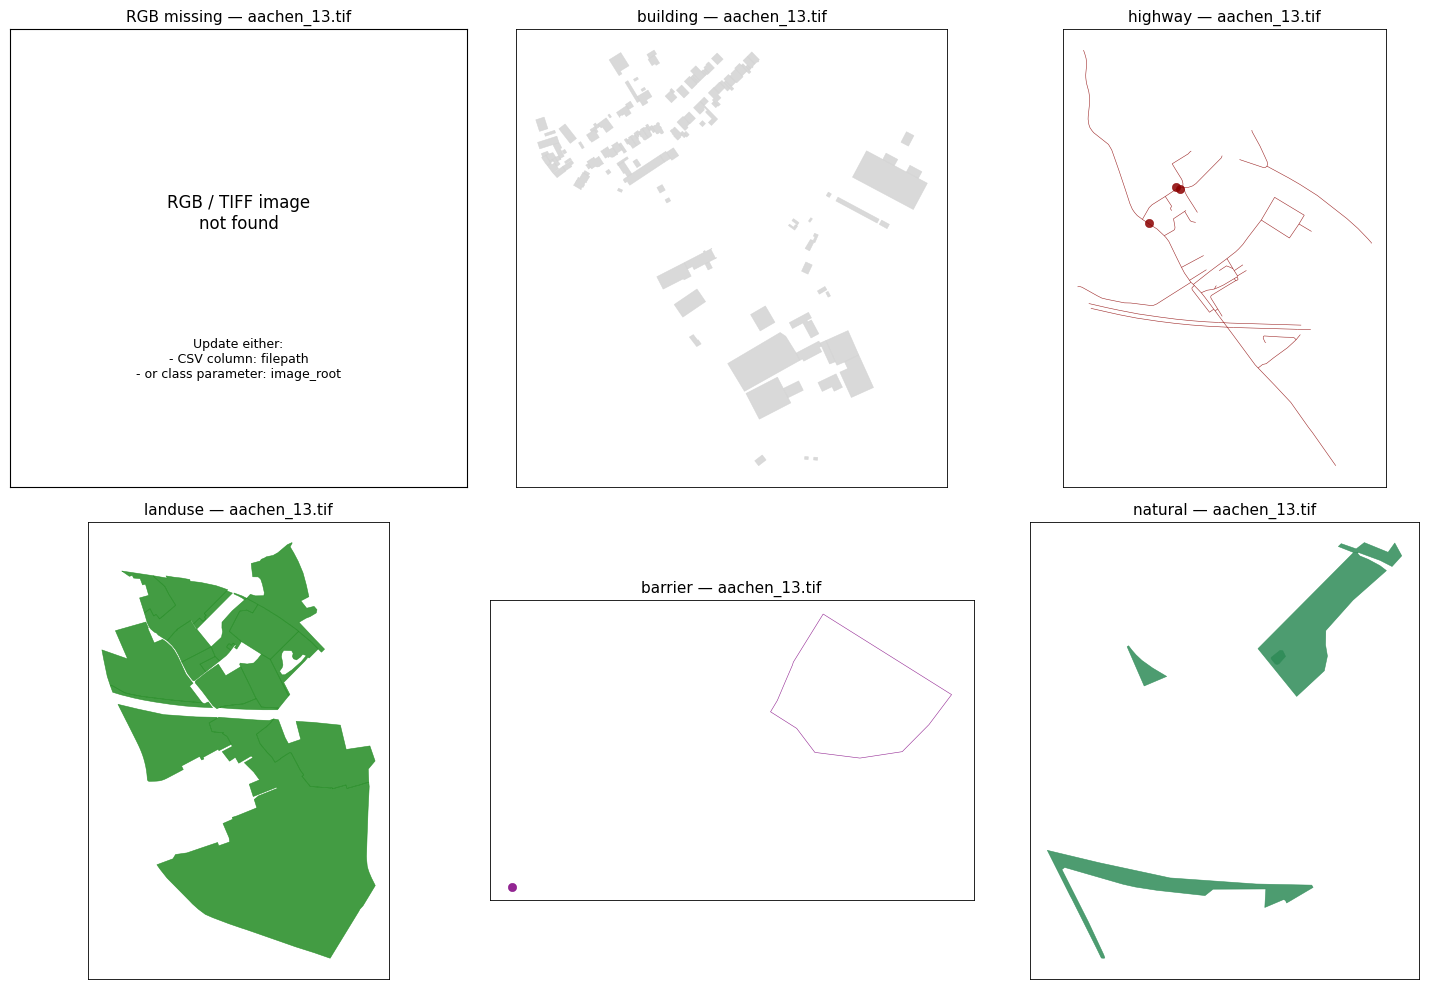

In [87]:
# ============================================================
# Cell 7 — Visualise selected OSM semantic layers for one patch
# ============================================================
#
# Purpose
# -------
# This cell loads the cached OSM vector file for one selected patch
# and visualises a chosen set of semantic OSM layers using the
# processor's built-in plotting function.
#
# Why this step is useful
# -----------------------
# After inspecting the available keys numerically, it is important
# to examine them spatially. This helps answer questions such as:
# - where are the buildings located?
# - how dense is the road network?
# - do land-use polygons match the expected patch content?
# - are natural or barrier features present in meaningful areas?
#
# What this cell does
# -------------------
# 1. selects one patch by filename
# 2. loads its cached OSM GeoPackage from disk
# 3. calls `plot_patch_rgb_and_keys(...)`
# 4. plots:
#    - the RGB patch image if available
#    - one panel for each selected OSM key
#
# Selected keys in this example
# -----------------------------
# - building :
#     built structures such as houses and other buildings
# - highway :
#     road and transport-related features
# - landuse :
#     land-use polygons such as grass, forest, residential, farmland, etc.
# - barrier :
#     boundary or blocking features such as fences, hedges, gates
# - natural :
#     natural features such as trees, scrub, water, wood, grassland
#
# Important note
# --------------
# If the RGB image is not found locally, the plotting function will
# show a placeholder panel instead of failing. This makes the cell
# usable even when only the OSM vector data is available.
# ============================================================

# Select one patch by filename.
# This patch should already have a cached OSM GeoPackage file saved
# inside the cache_vectors folder.
patch_id = "aachen_13.tif"

# Extract the filename stem without the ".tif" extension.
# This is used to build the name of the cached vector file.
patch_stem = Path(patch_id).stem

# Read the cached OSM vector data for the selected patch.
# The file is expected at:
#     osm_patch_outputs/cache_vectors/aachen_13.gpkg
patch_gdf = gpd.read_file(
    Path("osm_patch_outputs") / "cache_vectors" / f"{patch_stem}.gpkg"
)

# Plot the patch RGB image together with a selected set of OSM keys.
# The first panel is the RGB image (or a placeholder if unavailable),
# followed by one panel per requested semantic key.
processor.plot_patch_rgb_and_keys(
    # Patch identifier used to resolve metadata and, if possible, the image path
    patch_id=patch_id,

    # Preloaded GeoDataFrame for this patch, so the function does not need
    # to re-read or re-download the OSM data
    patch_gdf=patch_gdf,

    # Selected OSM semantic layers to visualise
    keys=["building", "highway", "landuse", "barrier", "natural"],
)

Loaded patch: kitsap_9.tif
Number of OSM features: 175


,element,id,button_operated,crossing,enforcement,highway,tactile_paving,traffic_signals:sound,traffic_signals:vibration,crossing:island,...,motor_vehicle,ski,snowmobile,vehicle,wheelchair,source,footway,natural,source_patch,geometry
0,node,48543743,yes,traffic_signals,traffic_signals,traffic_signals,yes,yes,yes,None,...,None,None,None,None,None,None,None,None,kitsap_9.tif,POINT (525305.389 5268648.426)
1,node,2957902522,yes,traffic_signals,None,crossing,yes,yes,yes,no,...,None,None,None,None,None,None,None,None,kitsap_9.tif,POINT (525317.535 5268638.098)
2,node,2957902523,yes,traffic_signals,None,crossing,yes,yes,yes,no,...,None,None,None,None,None,None,None,None,kitsap_9.tif,POINT (525319.105 5268659.444)
3,node,7467746471,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,kitsap_9.tif,POINT (525473.953 5268782.037)
4,node,8417126677,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,kitsap_9.tif,POINT (525474.167 5268626.232)



[Warning] RGB image could not be loaded.
Patch image not found for 'kitsap_9.tif'.
Checked the CSV 'filepath' value.
To fix this, either:
1. update the 'filepath' column in the patch metadata CSV, or
2. pass image_root='.../OpenEarthMap_wo_xBD' when creating OSMPatchProcessor.


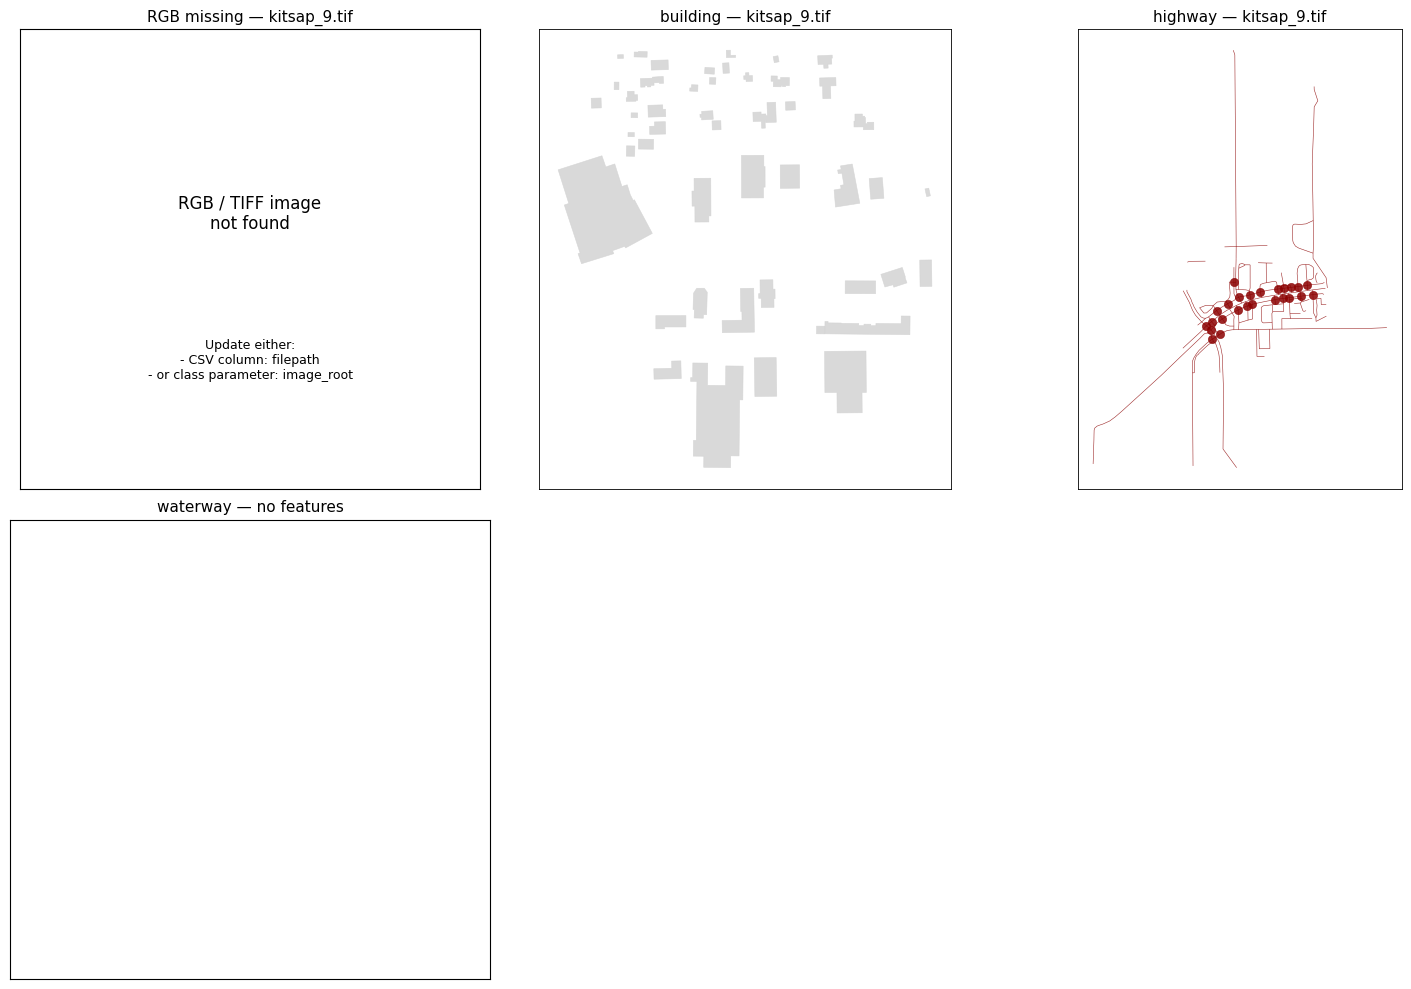

In [80]:

#Another example
patch_id = "kitsap_9.tif"
patch_stem = Path(patch_id).stem

patch_gdf = gpd.read_file(
    Path("osm_patch_outputs") / "cache_vectors" / f"{patch_stem}.gpkg"
)

print(f"Loaded patch: {patch_id}")
print(f"Number of OSM features: {len(patch_gdf)}")
display(patch_gdf.head())

processor.plot_patch_rgb_and_keys(
    patch_id=patch_id,
    patch_gdf=patch_gdf,
    keys=["building", "highway", "waterway"],
)

In [90]:
# ============================================================
# Cell 8 — Create binary masks for chosen classes
# ============================================================
#
# Purpose
# -------
# This cell creates one binary mask per selected semantic class
# for a single patch.
#
# What "binary mask" means
# ------------------------
# Each output mask contains:
# - 0 = background / absence of the class
# - 1 = presence of the class
#
# In this example
# ---------------
# We create binary masks for:
# - building
# - highway
# - waterway
#
# Output location
# ---------------
# By default, the masks will be saved inside a patch-specific folder:
#
#   osm_patch_outputs/binary_masks/<patch_name>/
#
# Example:
#   osm_patch_outputs/binary_masks/aachen_13/
#
# and files such as:
# - aachen_13_building_mask.tif
# - aachen_13_building_mask.png
# - aachen_13_highway_mask.tif
# - aachen_13_highway_mask.png
# ============================================================

# Select the patch to rasterise
patch_id = "aachen_13.tif"

# Create one binary mask per selected class
binary_masks = processor.export_binary_masks_for_patch(
    # Patch identifier from the metadata CSV
    patch_id=patch_id,

    # Semantic classes to include as separate binary masks
    selected_keys=["building", "highway", "waterway"],

    # If True, save PNG previews alongside the GeoTIFF masks
    save_png=True,
)

# Print a quick summary of the generated mask arrays
for class_name, mask in binary_masks.items():
    print(class_name, mask.shape, np.unique(mask))

Loading cached OSM features: osm_patch_outputs/cache_vectors/aachen_13.gpkg
building (1000, 1000) [0 1]
highway (1000, 1000) [0 1]
waterway (1000, 1000) [0]


In [91]:
# ============================================================
# Cell 9 — Create binary masks for all default semantic keys
# ============================================================
#
# Purpose
# -------
# This cell creates one binary mask for every default semantic
# OSM key defined inside the processor.
#
# Default semantic keys
# ---------------------
# If `selected_keys=None`, the processor uses:
# - building
# - highway
# - landuse
# - natural
# - waterway
# - railway
# - amenity
# - barrier
# - man_made
#
# When to use this
# ----------------
# This is useful for broad exploratory mask generation when you want
# to preserve all main semantic families before deciding which ones
# are most useful for your downstream task.
# ============================================================

patch_id = "aachen_13.tif"

binary_masks_all = processor.export_binary_masks_for_patch(
    patch_id=patch_id,

    # None means: use all default semantic keys
    selected_keys=None,

    save_png=True,
)

for class_name, mask in binary_masks_all.items():
    print(class_name, mask.shape, np.unique(mask))

Loading cached OSM features: osm_patch_outputs/cache_vectors/aachen_13.gpkg
building (1000, 1000) [0 1]
highway (1000, 1000) [0 1]
landuse (1000, 1000) [0 1]
natural (1000, 1000) [0 1]
waterway (1000, 1000) [0]
railway (1000, 1000) [0 1]
amenity (1000, 1000) [0 1]
barrier (1000, 1000) [0 1]
man_made (1000, 1000) [0 1]


In [92]:
# ============================================================
# Cell 10 — Create one multiclass mask for chosen classes
# ============================================================
#
# Purpose
# -------
# This cell creates a single multiclass mask for one patch.
#
# What "multiclass mask" means
# ----------------------------
# Unlike the binary case, here all selected classes are written into
# one raster image. Each class receives an integer ID.
#
# Default class-ID behaviour
# --------------------------
# If no explicit class_id_map is given, the processor assigns IDs
# automatically in the same order as `selected_keys`.
#
# Example in this cell
# --------------------
# selected_keys = ["building", "highway", "waterway"]
#
# then the class IDs will be assigned automatically as:
# - building = 1
# - highway  = 2
# - waterway = 3
#
# Background is always:
# - 0 = no selected class
#
# Output location
# ---------------
# By default, the mask will be saved in a patch-specific folder:
#
#   osm_patch_outputs/multiclass_masks/<patch_name>/
#
# Example:
#   osm_patch_outputs/multiclass_masks/aachen_13/aachen_13_multiclass_mask.tif
# ============================================================

patch_id = "aachen_13.tif"

multiclass_mask = processor.export_multiclass_mask_for_patch(
    patch_id=patch_id,

    # Selected semantic classes to include in the single multiclass mask
    selected_keys=["building", "highway", "waterway"],

    # Save PNG preview in addition to the GeoTIFF output
    save_png=True,
)

# Print the output mask shape and the unique values present in the mask
print(multiclass_mask.shape)
print(np.unique(multiclass_mask))

Loading cached OSM features: osm_patch_outputs/cache_vectors/aachen_13.gpkg
(1000, 1000)
[0 1 2]


In [93]:
# ============================================================
# Cell 13 — Inspect the saved output files for one patch
# ============================================================
#
# Purpose
# -------
# This cell lists the files generated for a selected patch so you can
# quickly verify that the mask-export step worked.
#
# This is useful for checking:
# - which binary masks were created
# - whether PNG previews were saved
# - whether the multiclass mask exists
# ============================================================

patch_id = "aachen_13.tif"
patch_stem = Path(patch_id).stem

binary_dir = Path("osm_patch_outputs") / "binary_masks" / patch_stem
multiclass_dir = Path("osm_patch_outputs") / "multiclass_masks" / patch_stem

print("Binary mask files:")
if binary_dir.exists():
    for p in sorted(binary_dir.iterdir()):
        print(" -", p.name)
else:
    print(" - folder not found")

print("\nMulticlass mask files:")
if multiclass_dir.exists():
    for p in sorted(multiclass_dir.iterdir()):
        print(" -", p.name)
else:
    print(" - folder not found")

Binary mask files:
 - aachen_13_amenity_mask.png
 - aachen_13_amenity_mask.tif
 - aachen_13_barrier_mask.png
 - aachen_13_barrier_mask.tif
 - aachen_13_building_mask.png
 - aachen_13_building_mask.tif
 - aachen_13_highway_mask.png
 - aachen_13_highway_mask.tif
 - aachen_13_landuse_mask.png
 - aachen_13_landuse_mask.tif
 - aachen_13_man_made_mask.png
 - aachen_13_man_made_mask.tif
 - aachen_13_natural_mask.png
 - aachen_13_natural_mask.tif
 - aachen_13_railway_mask.png
 - aachen_13_railway_mask.tif
 - aachen_13_waterway_mask.png
 - aachen_13_waterway_mask.tif

Multiclass mask files:
 - aachen_13_multiclass_mask.png
 - aachen_13_multiclass_mask.tif
